# Tutorial 3 · Linear classifiers, cropping and an L1 kernel
## 从同一份数据比较模型，别让实验条件悄悄换了

[Lecture 3](Lecture03.md) · [Python/NumPy](Lecture01.md#arrays) · [课程目录](README.md)

依据当前 Tutorial3.ipynb 的 68 个单元，按原顺序展开。原标题为 *Gender Classification from Face Images*。本笔记只把文件名提供的 0/1 当成给定基准标签，分析模型是否重现这些标注；标签与模型结果不能确立照片中人物的真实身份。参考代码和答案为整理者实现，不是教师解答。

本次练习包括：45×40 图像怎样变为向量，怎样在训练内部选 C，怎样读线性权重，怎样公平比较裁剪与自定义核。本数据很小，单次测试10张，错一张就变10个百分点，结论必须与这个限制一起读。

| 原任务 | 优先级 | 难度与卡点 | 掌握要求与依据 |
|---|---|---|---|
| Tutorial3，第4–16个单元 加载、展平、划分 | 核心必会 | 中；轴和顺序 | 核对形状、标签规则、同一批索引 |
| Tutorial3，第17–40个单元 LR/SVM | 核心必会 | 中；CV与测试 | 完成训练、评估、权重及错误分析 |
| Tutorial3，第41–63个单元 裁剪 | 核心必会 | 中；掩码尺寸 | 保持样本划分，检查改变的只有表示 |
| Tutorial3，第64–68个单元 自定义核 | 核心必会 | 高；两层参数循环 | 检查核矩阵形状、用CV选择α/C |

优先级依据当前原任务。数学卡点可选读[矩阵](../../learning/foundation-notes/MathForML.md#vectors-covariance)和[长度与距离](../../learning/foundation-notes/MathForML.md#projection)。


## 0. Parameters and provenance｜将实验约定写在最前面
保留原 `np.random.seed(100)` 和 80/20、`random_state=4487` 划分；图像沿用ZIP中的顺序。原任务未规定候选网格，本参考实现选择 C=10^-3,…,10^3（7个值），α=0.001/0.01/0.1/1，5折分层CV、shuffle=True、seed42。所有模型使用相同折划分。候选网格由本参考实现选定。

English: Preserve the instructor's data order and train/test split. Candidate grids and shuffled stratified CV are explicit reference-implementation choices.

In [1]:
from pathlib import Path
import os
import json, zipfile, fnmatch, io, hashlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib import image as mpimg
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from IPython.display import display
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'learning/course-notes-documents.json').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Run this notebook from the CityU-StudyNotes checkout.')
COURSE = Path(os.environ.get('COURSE_DATA_ROOT', str(REPO/'data'))).expanduser().resolve()
DATA=COURSE/'CS5489/Lecture3/Tutorial3/photos-bw.zip'
if not DATA.is_file():
    raise FileNotFoundError(f'Missing {DATA}; obtain the Canvas data and set COURSE_DATA_ROOT (see docs/DATA.md).')
NOTES=REPO/'CS5489/course-notes'; ASSETS=NOTES/'assets'
ASSETS.mkdir(exist_ok=True)
np.random.seed(100)
SPLIT_SEED=4487; CV_SEED=42
CS=np.logspace(-3,3,7); ALPHAS=[.001,.01,.1,1.]
plt.rcParams.update({'figure.figsize':(7,4),'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
print('Source SHA256:',hashlib.sha256(DATA.read_bytes()).hexdigest())

Source SHA256: 9adbd795bf63b2408ae08e6610a80d8c3475e7c1e2df37fa3759449aa04df6ee


<a id="data-input"></a>

## 1. Load and inspect｜一行不是一个像素，而是一张图
**原任务 Tutorial3，第4–16个单元 / Task:** 从ZIP内存读取图像，展示，展平、减0.5并划分。 / Load PNGs from ZIP without extracting, inspect them, flatten, center by 0.5, and split.

45行×40列=1800个像素。`reshape(50,-1)`后50行仍是50张图。原文件名首字母m映射1，否则映射0；这里只复现给定标签编码，并检查确实只有预期的m/f命名。

Image shape: (50, 45, 40) X: (50, 1800) range: (np.float64(-0.5), np.float64(0.5))


,split,size,label 0,label 1
0,all,50,20,30
1,train,40,15,25
2,test,10,5,5


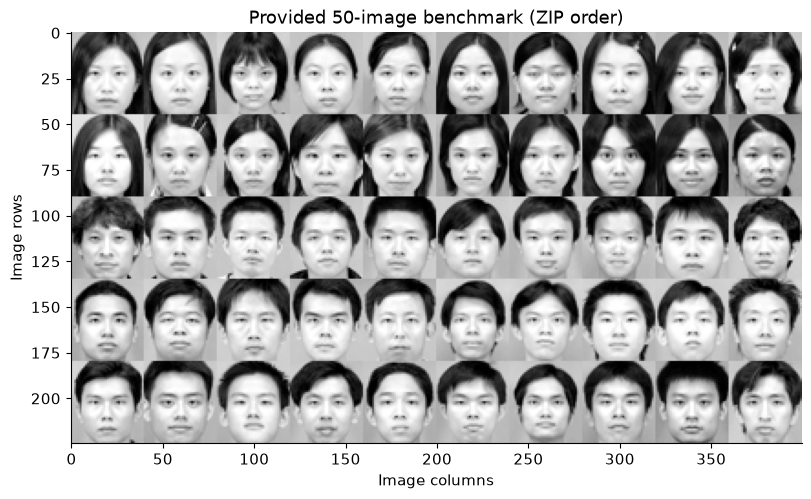

In [2]:
with zipfile.ZipFile(DATA) as z:
    names=[s for s in z.namelist() if fnmatch.fnmatch(s,'photos-bw/*.png')]
    assert all(Path(s).name[0] in 'mf' for s in names)
    images=np.stack([mpimg.imread(io.BytesIO(z.read(s)),format='png') for s in names])
Y=np.array([int(Path(s).name.startswith('m')) for s in names])
assert images.shape==(50,45,40) and np.isfinite(images).all()
assert images.min()>=0 and images.max()<=1
X=images.reshape(len(images),-1).astype(float)-.5
train_idx,test_idx=train_test_split(np.arange(len(Y)),train_size=.8,test_size=.2,random_state=SPLIT_SEED)
trainY,testY=Y[train_idx],Y[test_idx]
assert len(train_idx)==40 and len(test_idx)==10 and not set(train_idx)&set(test_idx)
folds=list(StratifiedKFold(5,shuffle=True,random_state=CV_SEED).split(X[train_idx],trainY))
print('Image shape:',images.shape,'X:',X.shape,'range:',(X.min(),X.max()))
display(pd.DataFrame({'split':['all','train','test'],'size':[50,40,10],
    'label 0':[sum(Y==0),sum(trainY==0),sum(testY==0)],'label 1':[sum(Y==1),sum(trainY==1),sum(testY==1)]}))
def montage(a,shape,maxw=10):
    if len(a)==0: return np.full(shape,.5)
    a=np.asarray(a).reshape(-1,*shape); rows=int(np.ceil(len(a)/maxw)); width=min(maxw,len(a))
    canvas=np.full((rows*shape[0],width*shape[1]),.5)
    for j,img in enumerate(a): canvas[(j//width)*shape[0]:(j//width+1)*shape[0],(j%width)*shape[1]:(j%width+1)*shape[1]]=img
    return canvas
fig,ax=plt.subplots(figsize=(8,5),layout='constrained');ax.imshow(montage(images,(45,40)),cmap='gray',vmin=0,vmax=1)
ax.set(title='Provided 50-image benchmark (ZIP order)',xlabel='Image columns',ylabel='Image rows')
fig.savefig(ASSETS/'tut03-input-montage.png',dpi=160);plt.show()

固定减0.5不需要从测试数据估计任何量，所以可以在划分前做。这里不额外加标准化，以对应原任务；若以后加入估计均值/标准差的变换，必须放在每折训练的Pipeline里。

**自查 / Check:** 为什么不能裁剪后重新随机划分再比较？ / Why not randomly split again after cropping?
**答 / Answer:** 差异会同时包含表示变化与样本难度变化，无法归因。 / The comparison would confound representation changes with different test examples.


## 2. Logistic regression｜选C只看训练内部的验证表现
**原任务 Tutorial3，第17–22个单元 / Task:** CV选择C，报告训练和测试准确率。 / Select C using CV and report train/test accuracy.

代码先在40张训练图内部做5折，每折32训练/8验证；最佳C再用40张重训。测试10张从不参与选C。候选并列时GridSearchCV采用候选顺序中的第一个，这是执行约定，不是更小C一定更好的证明。

,model,features,C,CV accuracy,train accuracy,test accuracy
0,LR full,1800,0.1,0.9,0.95,0.8


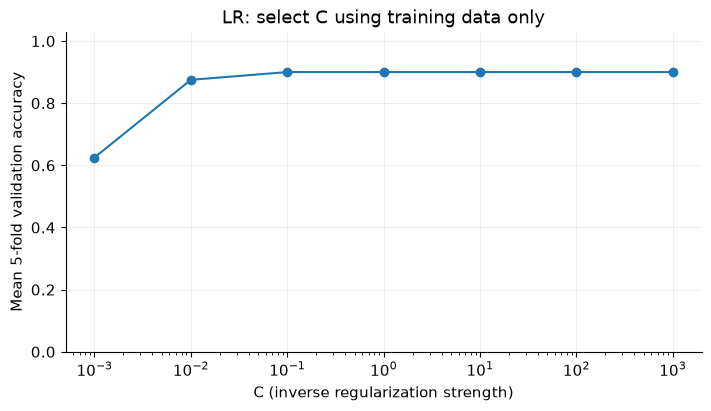

In [3]:
models={}; rows=[]
def fit_linear(key,features,kind):
    estimator=LogisticRegression(max_iter=5000,solver='lbfgs') if kind=='LR' else SVC(kernel='linear')
    search=GridSearchCV(estimator,{'C':CS},cv=folds,scoring='accuracy',n_jobs=1,return_train_score=False,error_score='raise')
    search.fit(features[train_idx],trainY); models[key]=search
    row={'model':key,'features':features.shape[1],'C':float(search.best_params_['C']),
         'CV accuracy':float(search.best_score_),
         'train accuracy':accuracy_score(trainY,search.predict(features[train_idx])),
         'test accuracy':accuracy_score(testY,search.predict(features[test_idx]))}
    rows.append(row);return search
lr=fit_linear('LR full',X,'LR')
display(pd.DataFrame(rows))
fig,ax=plt.subplots(layout='constrained');ax.semilogx(CS,lr.cv_results_['mean_test_score'],'o-')
ax.set(xlabel='C (inverse regularization strength)',ylabel='Mean 5-fold validation accuracy',title='LR: select C using training data only',ylim=(0,1.03));ax.grid(alpha=.2)
fig.savefig(ASSETS/'tut03-lr-cv.png',dpi=160);plt.show()


## 3. Weight image and errors｜权重回答的是“哪些像素推动分数”
**原任务 Tutorial3，第23–29个单元 / Task:** 显示w、正确/错分样本并解释。 / Visualize coefficients and correct/incorrect benchmark predictions.

$f(x)=\sum_jw_jx_j+b$。正w配较亮像素，或负w配较暗像素，都能使给定标签1的分数增加。例如其他像素不变时，一个像素变亮0.1，它对分数的改变量就是0.1w。相关像素可能分摊权重，因此读图时也要看周围区域的共同变化。标签含义与研究范围沿用开头说明。

平均图沿用老师的全部数据展示，仅用来观察图像，不进入训练（Tutorial3，第16个单元）；这里同样展示完整平均图并明确它不是模型输入变换。错误分组只表示与给定基准标签是否一致。

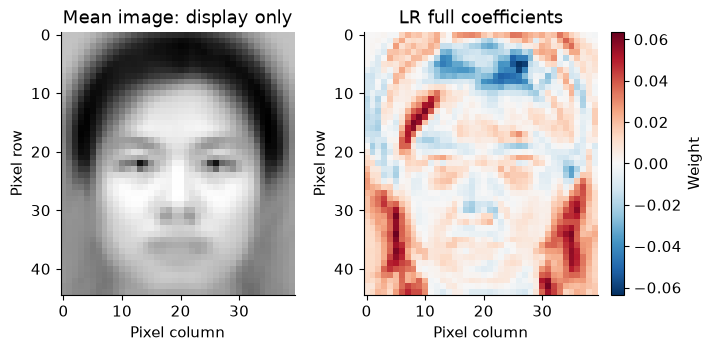

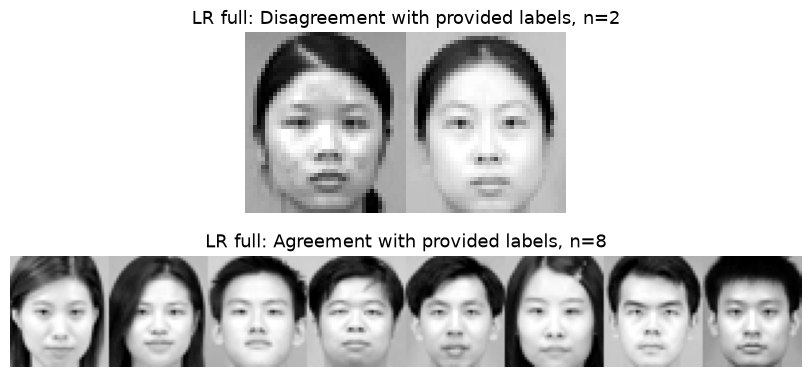

,predicted 0,predicted 1
given 0,3,2
given 1,0,5


In [4]:
def show_weights(search,features,shape,key):
    w=search.best_estimator_.coef_.reshape(shape); limit=max(abs(w.min()),abs(w.max()))
    fig,axs=plt.subplots(1,2,figsize=(7,3.4),layout='constrained')
    axs[0].imshow(features.mean(axis=0).reshape(shape),cmap='gray');axs[0].set_title('Mean image: display only')
    im=axs[1].imshow(w,cmap='RdBu_r',vmin=-limit,vmax=limit);axs[1].set_title(key+' coefficients')
    for ax in axs: ax.set(xlabel='Pixel column',ylabel='Pixel row')
    fig.colorbar(im,ax=axs[1],label='Weight');fig.savefig(ASSETS/(key.replace(' ','-').lower()+'-weights.png'),dpi=160);plt.show()
    # Algebra check: coefficient image and estimator produce the same score.
    direct=features[test_idx]@search.best_estimator_.coef_.ravel()+search.best_estimator_.intercept_[0]
    assert np.allclose(direct,search.decision_function(features[test_idx]))
def show_errors(search,features,shape,key):
    pred=search.predict(features[test_idx]);bad=pred!=testY
    fig,axs=plt.subplots(2,1,figsize=(8,4),layout='constrained')
    for ax,mask,title in zip(axs,[bad,~bad],['Disagreement with provided labels','Agreement with provided labels']):
        ax.imshow(montage(features[test_idx][mask]+.5,shape),cmap='gray',vmin=0,vmax=1)
        ax.set_title(f'{key}: {title}, n={mask.sum()}');ax.set_axis_off()
    fig.savefig(ASSETS/(key.replace(' ','-').lower()+'-errors.png'),dpi=160);plt.show()
    display(pd.DataFrame(confusion_matrix(testY,pred,labels=[0,1]),index=['given 0','given 1'],columns=['predicted 0','predicted 1']))
show_weights(lr,X,(45,40),'LR full');show_errors(lr,X,(45,40),'LR full')

**输出怎样读 / Reading:** 先读混淆矩阵，再看错误组共有几张，最后提出能检验的原因，例如外围像素是否贡献较大。仅看一张错分图不能确定原因；后面的裁剪是一个干预比较。 / Read the confusion matrix and error count before forming hypotheses. A single misclassified image does not establish a cause; cropping provides a controlled representation comparison.


## 4. Linear SVM｜换目标，保持数据不变
**原任务 Tutorial3，第30–40个单元 / Task:** 在相同划分上训练线性SVM，CV选C，比较准确率、权重和错误。 / Repeat with a linear SVM on the same split and compare accuracy, weights, and errors.

LR的logistic loss与SVM的hinge loss对边界附近样本的处理不同，不能期望w完全一致。系数绝对大小也不能脱离目标函数与C直接比较。以下统一色图含义，分别标注各图的数值范围。

,model,features,C,CV accuracy,train accuracy,test accuracy
0,LR full,1800,0.10,0.9,0.950,0.8
1,SVM full,1800,0.01,0.9,0.925,0.8


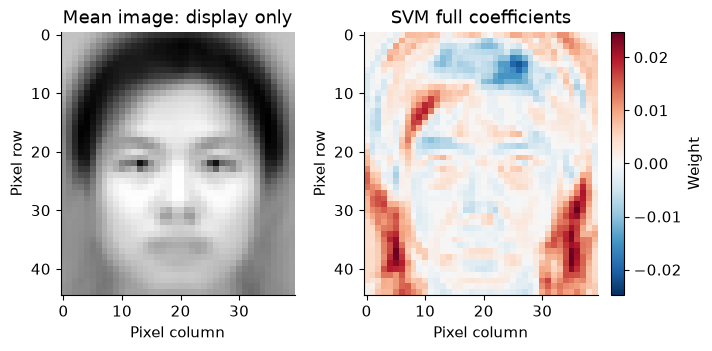

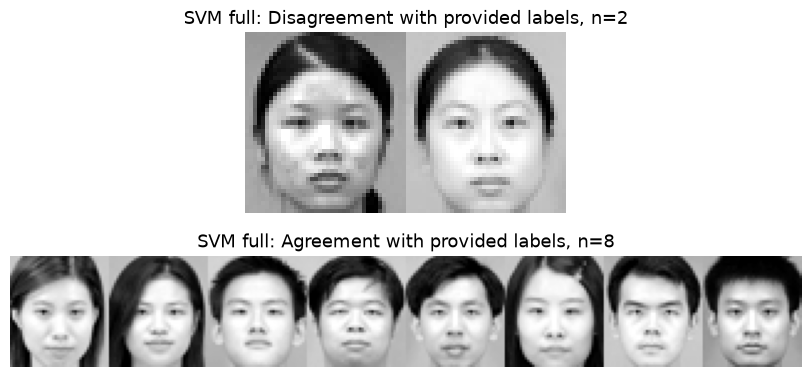

,predicted 0,predicted 1
given 0,3,2
given 1,0,5


Coefficient-direction cosine: 0.9439830620502164


In [5]:
sv=fit_linear('SVM full',X,'SVM')
display(pd.DataFrame(rows));show_weights(sv,X,(45,40),'SVM full');show_errors(sv,X,(45,40),'SVM full')
w1=lr.best_estimator_.coef_.ravel();w2=sv.best_estimator_.coef_.ravel()
print('Coefficient-direction cosine:',float(w1@w2/(np.linalg.norm(w1)*np.linalg.norm(w2))))

**English:** Different losses and regularization settings can produce different coefficient patterns. Similar performance does not imply identical decision rules.


## 5. Crop the same images｜先查尺寸，再解释性能
**原任务 Tutorial3，第41–63个单元 / Task:** 使用掩码、同一划分，重训LR/SVM并解释变化。 / Crop with the given mask, preserve the split, and repeat LR/SVM experiments.

当前实际代码是 `[18:40,11:29]`，Python右端不含：高22、宽18，共396维。原Tutorial3，第44个单元仍说24×24、576维，对应被注释掉的旧掩码，不是本次实际输入。裁剪既减少外围信息，也可能丢掉有用信号，效果由后面的比较检验。

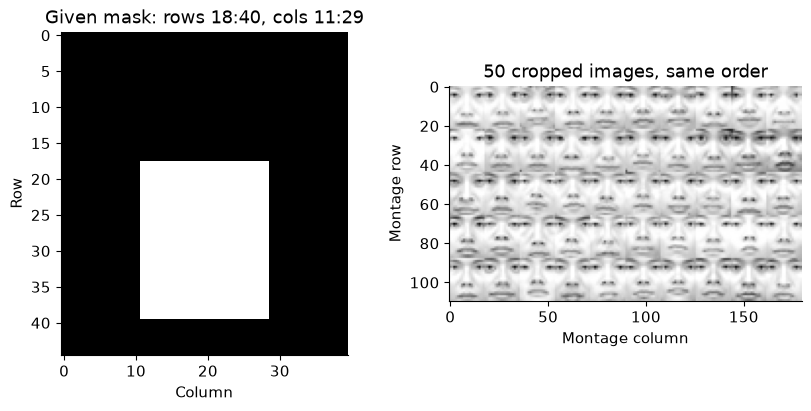

,model,features,C,CV accuracy,train accuracy,test accuracy
0,LR full,1800,0.10,0.900,0.950,0.8
1,SVM full,1800,0.01,0.900,0.925,0.8
2,LR crop,396,1.00,0.850,0.975,0.8
3,SVM crop,396,10.00,0.825,1.000,0.9


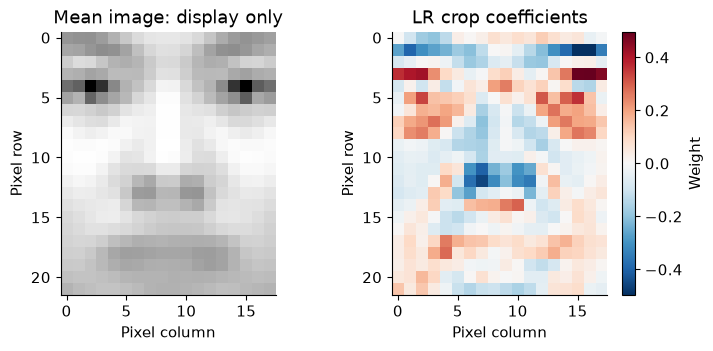

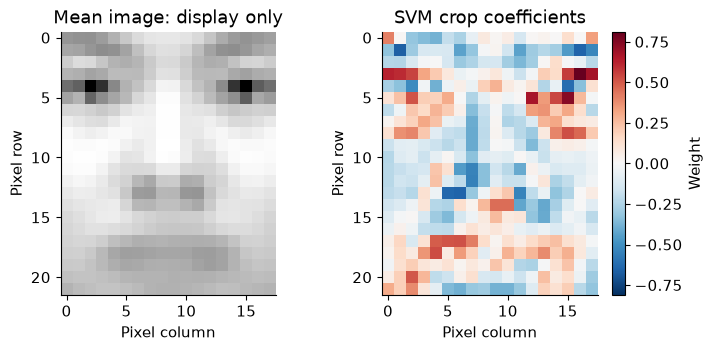

In [6]:
mask=np.zeros((45,40),dtype=bool);mask[18:40,11:29]=True
Xm=X[:,mask.ravel()]; assert Xm.shape==(50,396)
assert np.array_equal(Xm.reshape(50,22,18),images[:,18:40,11:29].astype(float)-.5)
fig,axs=plt.subplots(1,2,figsize=(8,4),layout='constrained')
axs[0].imshow(mask,cmap='gray',vmin=0,vmax=1);axs[0].set(title='Given mask: rows 18:40, cols 11:29',xlabel='Column',ylabel='Row')
axs[1].imshow(montage(Xm+.5,(22,18)),cmap='gray',vmin=0,vmax=1);axs[1].set(title='50 cropped images, same order',xlabel='Montage column',ylabel='Montage row')
fig.savefig(ASSETS/'tut03-crop.png',dpi=160);plt.show()
lr_crop=fit_linear('LR crop',Xm,'LR');sv_crop=fit_linear('SVM crop',Xm,'SVM')
display(pd.DataFrame(rows))
show_weights(lr_crop,Xm,(22,18),'LR crop');show_weights(sv_crop,Xm,(22,18),'SVM crop')

In [7]:
mask_flat=mask.ravel()
for key in ['LR full','SVM full']:
    w=models[key].best_estimator_.coef_.ravel()
    share=float(np.sum(w[~mask_flat]**2)/np.sum(w**2))
    print(f'{key}: fraction of squared coefficient magnitude outside crop = {share:.3f}')
for key in ['LR','SVM']:
    full=next(r for r in rows if r['model']==key+' full');crop=next(r for r in rows if r['model']==key+' crop')
    print(f'{key}: test accuracy change after cropping = {crop["test accuracy"]-full["test accuracy"]:+.3f}')

LR full: fraction of squared coefficient magnitude outside crop = 0.952
SVM full: fraction of squared coefficient magnitude outside crop = 0.963
LR: test accuracy change after cropping = +0.000
SVM: test accuracy change after cropping = +0.100


这里的比例把外围像素的系数平方相加，再除以全部系数平方和，描述的是权重集中在哪里。它没有统计这些像素让模型多分对多少张图片。裁剪前后的预测表现，需要另外比较下面的CV和测试结果。

**变式 / Transfer:** 若改用 `[17:41,8:32]`，输入几维？能沿用396维权重吗？ / What dimension follows from this alternative crop, and can 396-dimensional weights be reused?
**答 / Answer:** 24×24=576维；不能，特征坐标和模型需要重新匹配并训练。 / 576 dimensions; the coordinates and model must be rebuilt and refitted.


## 6. Custom kernel｜先用两个小向量检查，再接入SVM
**原任务 Tutorial3，第64–68个单元 / Task:** 实现 $k(x,y)=\exp(-\alpha\sum_j|x_j-y_j|)$；外层试α、内层CV选C，比较结果。 / Implement the L1 kernel, select alpha and C by training-only CV, and compare results.

例如 x=(0,1)、y=(2,1)，L1距离=2，α=0.5时核值 $e^{-1}\approx0.3679$。训练输入(A,A)给40×40，预测输入(B,A)给10×40。不是写一个只处理单个向量的函数就够。

原文字称它总比RBF衰减慢，需要限定距离尺度：一维同系数时 d>1 有 $e^{-d}>e^{-d^2}$，但0<d<1时反过来。不同维度、尺度、α/γ不能直接套这个比较。

In [8]:
def l1_kernel(A,B,alpha=1.):
    A=np.asarray(A);B=np.asarray(B)
    if A.ndim!=2 or B.ndim!=2 or A.shape[1]!=B.shape[1] or alpha<=0:
        raise ValueError('Two 2D matrices with matching feature counts and positive alpha are required.')
    return np.exp(-alpha*cdist(A,B,metric='cityblock'))
assert np.isclose(l1_kernel([[0.,1.]],[[2.,1.]],alpha=.5)[0,0],np.exp(-1))
K=l1_kernel(Xm[train_idx],Xm[train_idx],.01)
assert K.shape==(40,40) and np.allclose(K,K.T) and np.allclose(np.diag(K),1)
assert np.linalg.eigvalsh(K).min()>-1e-9 # Implementation check, not a general proof.
assert l1_kernel(Xm[test_idx],Xm[train_idx]).shape==(10,40)
kernel_runs=[]
for alpha in ALPHAS:
    # Binding alpha in the default argument avoids the late-binding loop bug.
    kernel=lambda A,B,alpha=alpha:l1_kernel(A,B,alpha)
    search=GridSearchCV(SVC(kernel=kernel),{'C':CS},cv=folds,scoring='accuracy',n_jobs=1,error_score='raise')
    search.fit(Xm[train_idx],trainY)
    kernel_runs.append((alpha,search))
best_alpha,best_kernel=max(kernel_runs,key=lambda pair:pair[1].best_score_)
display(pd.DataFrame([{'alpha':a,'best C':s.best_params_['C'],'CV accuracy':s.best_score_} for a,s in kernel_runs]))
kernel_row={'model':'L1 SVM crop','features':396,'C':float(best_kernel.best_params_['C']),
    'CV accuracy':float(best_kernel.best_score_),'train accuracy':accuracy_score(trainY,best_kernel.predict(Xm[train_idx])),
    'test accuracy':accuracy_score(testY,best_kernel.predict(Xm[test_idx]))}
rows.append(kernel_row)
print('Selected alpha:',best_alpha)

,alpha,best C,CV accuracy
0,0.001,100.000,0.850
1,0.010,10.000,0.875
2,0.100,10.000,0.700
3,1.000,0.001,0.625


Selected alpha: 0.01


同一CV折反复比较α和C是训练内部调参，本身允许；选出的最高CV分数会带有选择乐观性，不能把它当无偏泛化估计。`SVC`的非线性核没有可直接reshape为输入图像的普通w；不能把线性权重图代码硬套上去。

,model,features,C,CV accuracy,train accuracy,test accuracy
0,LR full,1800,0.10,0.900,0.950,0.8
1,SVM full,1800,0.01,0.900,0.925,0.8
2,LR crop,396,1.00,0.850,0.975,0.8
3,SVM crop,396,10.00,0.825,1.000,0.9
4,L1 SVM crop,396,10.00,0.875,1.000,0.9


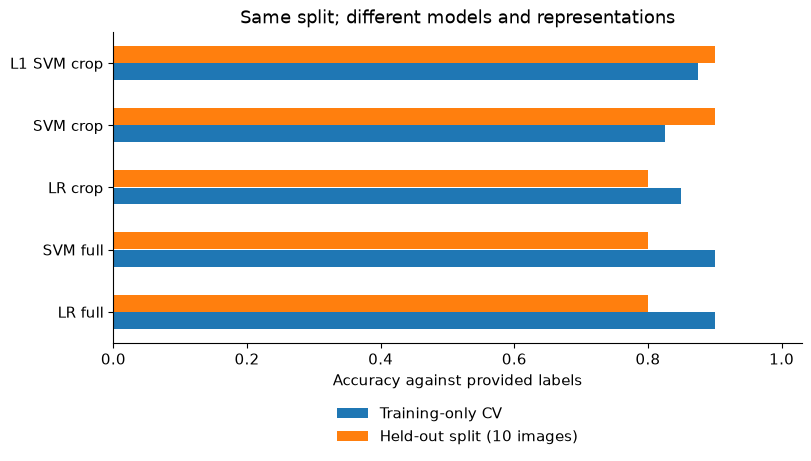

L1 kernel minus best cropped linear test accuracy: +0.000
Interpret only this provided benchmark and split; one test image changes accuracy by 0.10.


1789

In [9]:
comparison=pd.DataFrame(rows);display(comparison)
fig,ax=plt.subplots(figsize=(8,4.5),layout='constrained')
pos=np.arange(len(rows));ax.barh(pos-.14,comparison['CV accuracy'],height=.27,label='Training-only CV')
ax.barh(pos+.14,comparison['test accuracy'],height=.27,label='Held-out split (10 images)')
ax.set(yticks=pos,yticklabels=comparison['model'],xlabel='Accuracy against provided labels',xlim=(0,1.03),title='Same split; different models and representations')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.16),frameon=False,ncol=1);fig.savefig(ASSETS/'tut03-comparison.png',dpi=160);plt.show()
baseline=max(r['test accuracy'] for r in rows if r['model'] in ['LR crop','SVM crop'])
delta=kernel_row['test accuracy']-baseline
print(f'L1 kernel minus best cropped linear test accuracy: {delta:+.3f}')
print('Interpret only this provided benchmark and split; one test image changes accuracy by 0.10.')
result={'source_sha256':hashlib.sha256(DATA.read_bytes()).hexdigest(),'image_shape':list(images.shape),'crop_shape':[22,18],
        'train_indices':train_idx.tolist(),'test_indices':test_idx.tolist(),'train_seed':SPLIT_SEED,'cv_seed':CV_SEED,
        'C_candidates':CS.tolist(),'alpha_candidates':ALPHAS,'selected_alpha':best_alpha,'models':rows,
        'all_checks_passed':True,'scope':'Provided filename labels, not a claim about individual identity.'}
(NOTES/'tutorial03-results.json').write_text(json.dumps(result,ensure_ascii=False,indent=2)+'\n')


## 本轮结果解读 / Interpreting this run

保存结果后出现的单独整数是 `write_text` 返回的写入字符数，不是模型得分。 / The standalone integer after saving is the character count returned by `write_text`, not a model score.

完整图像的LR与线性SVM在10张测试图上均为0.80（2张与给定标签不一致），两组系数方向余弦约0.944，说明规则相似但并不相同。外围被裁掉部分占完整图系数平方和约95.2%/96.3%；它表示系数平方主要集中在外围，具体定义见裁剪部分。

裁剪后LR测试仍0.80、SVM为0.90，但其CV分别从0.90降到0.85/0.825。这个不一致提醒我们：单个10张测试划分波动很大，不能只凭多分对一张就宣布裁剪普遍更优。L1核选择α=0.01、C=10，CV=0.875、测试0.90，与裁剪线性SVM测试相同；没有在这份测试上进一步提高。

**English:** Full-image LR and linear SVM both scored 0.80 on the ten-image split. Cropped LR scored 0.80 and cropped linear SVM 0.90, despite lower CV scores. The selected L1 kernel (alpha=0.01, C=10) scored 0.875 in CV and 0.90 on the held-out split, tying the cropped linear SVM. The held-out set contains only ten images, so each changed prediction moves accuracy by ten percentage points.

这些数值对应上述固定数据、划分和候选网格。


## 7. Independent explanation and source coverage｜合上代码，说清实验

1. **How are 45×40 pixels converted to the model input? / 怎样转成输入？** 每图按一致顺序展平为1800维，一行一图；训练预测顺序相同。 / Flatten consistently into 1800 features per image.
2. **Why is C selected without test labels? / 为什么选C不看测试标签？** 防止选择过程适应测试集。 / To keep model selection from adapting to the held-out evaluation set.
3. **What happens to the score if one pixel increases by 0.1? / 一个像素增加0.1，其他值不变，分数怎样变？** 改变0.1乘该像素系数；符号决定升高还是降低。 / It changes by 0.1 times that pixel coefficient; the sign determines the direction.
4. **If the L1 model ties the linear model on ten images, is it superior? / 10张上平局能证明优越吗？** 不能；需更多独立证据，也要比较复杂度。 / No; more independent evidence and complexity considerations are needed.

参考[已有微课](https://crazyshout.github.io/micro-course/?lesson=ml12)与Lecture3末尾的卡片入口。先能解释实验中的每个选择，再刷卡记住原则。

| 原单元 | 本笔记位置与处理 |
|---|---|
| 1–3 | 开篇、§0：身份栏不代填；保留原种子 |
| 4–16 | §1：ZIP、尺寸、全部图、展平、中心化、固定划分；平均图仅展示 |
| 17–22 | §2：LR、CV和训练/测试输出 |
| 23–29 | §3：权重、错分/正确组、限制与待验证原因 |
| 30–40 | §4：SVM同条件比较、权重方向与错误 |
| 41–50 | §5：实际22×18掩码、396维、同一索引、平均图 |
| 51–63 | §5：裁剪LR/SVM、性能、权重、独立变式 |
| 64–68 | §6：L1核、手算/形状检查、α/C选择、实际比较；空单元无需占位 |

上述结果来自本参考实现，参数和划分见§0。原题未指定唯一的最优参数。